# Generative Adversarial Networks



## The Intuition: The Art Forger vs. The Art Detective

Imagine a game played between two people: an Art Forger (the Generator) and an Art Detective (the Discriminator).

- The Forger creates fake paintings and tries to pass them off as authentic.

- The Detective examines paintings and tries to guess if they are real (from a museum) or fake (from the Forger).

This is a Zero-Sum Game: whatever the Forger wins, the Detective loses, and vice versa. If the Forger successfully tricks the Detective, the Forger gets a point (+1) and the Detective loses a point (-1). Their scores always add up to zero.

This is also a Minimax Game: The Forger wants to minimize the Detective's success rate, while the Detective wants to maximize their own success rate. They are pulling in opposite directions.

What is the endgame? (Nash Equilibrium)
As they play, they both get better. The Forger's paintings become indistinguishable from museum pieces. The Detective becomes an absolute expert at spotting flaws.

Eventually, they reach a stalemate. The Forger makes perfect fakes, meaning the Detective has absolutely no way to tell the difference. The Detective is forced to flip a coin, guessing "Real" 50% of the time and "Fake" 50% of the time.

In Game Theory, this stalemate is called a Nash Equilibrium. At this point, neither player can change their strategy to get a better score, because the Generator has perfectly replicated the real data.

## The Architecture: From Players to Neural Networks

![GAN](notebook_images/gan.jpg) 


To turn this game into a Deep Learning model, we replace the Forger and the Detective with two distinct neural networks, and we pass data between them:

The Generator Network ($G$): This is our Forger. It takes a vector of random noise (called the latent vector, $z$) as input and passes it through its layers to generate a synthetic image. We call this output $G(z)$.

The Discriminator Network ($D$): This is our Detective. It takes an image as input—either a real training image ($x$) or a fake generated image ($G(z)$). It acts as a binary classifier, outputting a single probability value between 0 and 1.

$D(x)$ is the probability that a real image is classified as real.

$D(G(z))$ is the probability that a fake image is classified as real.

During a training step, the Discriminator evaluates a batch of real images and a batch of fakes. The Discriminator tweaks its weights to push $D(x)$ toward 1.0 and $D(G(z))$ toward 0.0. Simultaneously, the Generator tweaks its own weights to create better images, trying to force $D(G(z))$ toward 1.0.

While the original GANs used simple fully-connected layers, in this notebook we will specifically build a Deep Convolutional GAN (DCGAN), which leverages convolutional layers to generate much higher quality images (Radford et al., 2015).

## The Math: Minimax and Nash Equilibrium

In a GAN, the Generator ($G$) and Discriminator ($D$) play this exact zero-sum game using a mathematical loss function, $V(G,D)$.

The objective of the GAN is written as a Minimax optimization problem:

$$\min_𝐺\max_𝐷 𝑉(𝐺,𝐷)$$

Here is what that means for each network:

The Discriminator's Goal ($\max_D$): The Discriminator wants to maximize the function $V$. It wants to output a probability of $1.0$ when it sees a real image, and $0.0$ when it sees a fake image.

The Generator's Goal ($\min_G$): The Generator wants to minimize the function $V$. It wants to create images so realistic that the Discriminator is tricked into outputting $1.0$ for the fakes.

Reaching the Nash Equilibrium
The mathematical definition of a Nash equilibrium in a GAN occurs when the Generator's data distribution exactly matches the real data distribution ($p_g = p_{data}$).

When this happens, the Discriminator can no longer distinguish real from fake, so its output becomes exactly $D(x) = 0.5$ for every image it sees. At this point, the game is solved, and training is theoretically complete.


### References:

**Foundational Papers**

- Generative Adversarial NetworksGenerative Adversarial Networks, Ian J. Goodfellow, Jean Pouget-Abadie, Mehdi Mirza, Bing Xu, David Warde-Farley, Sherjil Ozair, Aaron Courville, Yoshua Bengio, https://arxiv.org/abs/1406.2661
- Unsupervised Representation Learning with Deep Convolutional Generative Adversarial NetworksUnsupervised Representation Learning with Deep Convolutional Generative Adversarial Networks, Alec Radford, Luke Metz, Soumith Chintala, https://arxiv.org/abs/1511.06434

**Tutorials**

- NIPS 2016 Tutorial: Generative Adversarial Networks, Ian Goodfellow (2016). https://arxiv.org/abs/1701.00160 
- Ahlad Kumar, Deep Learning 27 - 37: GAN and WGAN, https://www.youtube.com/watch?v=RRTuumxm3CE



In [43]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms

import torchinfo

import matplotlib.pyplot as plt
from matplotlib import colors
from matplotlib.patches import Rectangle

import numpy as np
import time

import os
import pathlib
from PIL import Image
import skimage
from tqdm import tqdm

# importing a module with utilities for displaying stats and data
import sys
sys.path.insert(1, 'util')
import vcpi_util

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(device)

cuda:0


## Auxiliary functions

In [44]:
def show_images(rows, cols, images):

    width  = 2 * cols
    height = 2 * rows

    f, axes = plt.subplots(rows, cols, figsize=(width, height))

    for a in range(rows * cols):

        axes.ravel()[a].imshow(np.clip(np.transpose(images[a].numpy(), (1, 2, 0)) * 0.5 + 0.5, 0, 1),
                               cmap=plt.cm.gray)
        axes.ravel()[a].axis('off')

    f.tight_layout()
    plt.show()


def load(checkpoint_path):
    # 1. Re-instantiate the models and optimizers so they exist in memory
    G = Generator(LATENT_SPACE_DIM).to(device)
    D = Discriminator().to(device)

    # 2. Load the weights from the file
    if os.path.exists(checkpoint_path):
        print(f"Loading checkpoint from {checkpoint_path}...")
        
        # Load the dictionary onto the correct device
        checkpoint = torch.load(checkpoint_path, map_location=device)
        
        # Load states into our instantiated objects
        G.load_state_dict(checkpoint['generator'])
        D.load_state_dict(checkpoint['discriminator'])
        print(f"Successfully loaded! Model trained for {start_epoch} epochs.")
        
        # Set to evaluation mode for metric testing
        G.eval()
        D.eval()
        return D, G
    else:
        print(f"Warning: Checkpoint file '{checkpoint_path}' not found.")
        print("You must run the training loop above before evaluating.")
        return None, None

## Configuration

In [45]:
# Same latent dim as used in the AE notebooks — allows fair comparison
# and has been shown to be sufficient for MNIST reconstruction quality
LATENT_SPACE_DIM = 16
BATCH_SIZE = 32

TRAIN = False

## A Note on Latent Space: GANs vs. Autoencoders

In previous notebooks, we used a latent dimension of 16 for Autoencoders. While we use 16 here as well, its purpose is fundamentally different:

- In an Autoencoder: The latent space acts as an information bottleneck. It is a deterministic compression. A latent dimension of 16 means the network is forced to throw away redundant pixels and memorize only the 16 most critical features to rebuild the original image.

- In a GAN: The latent space ($z$) acts as a prior distribution (a seed of entropy). It dictates the degrees of freedom the Generator has to explore the data manifold. A latent dimension of 16 means the Generator has 16 independent knobs of randomness it can combine to synthesize a digit. In an ideal GAN one knob might learn to control slant, another thickness, another the digit class. However, vanilla GANs can produce a highly entangled latent space, meaning that adjusting one knob might change not a single individual feature, but a set of features.

<em>"The GAN formulation uses a simple factored continuous input noise vector z, while imposing no restrictions on the manner in which the generator may use this noise. As a result, it is possible that the noise will be used by the generator in a highly entangled way, causing the individual dimensions of z to not correspond to semantic features of the data" </em>

— Source: InfoGAN: Interpretable Representation Learning by Information Maximizing Generative Adversarial Nets (Xi Chen et al., 2016). https://arxiv.org/pdf/1606.03657 

# The DCGAN Architecture

The original GAN (Goodfellow et al., 2014) used simple Multi-Layer Perceptrons (Fully Connected layers) for both the Generator and Discriminator. While groundbreaking, it struggled to generate high-resolution, coherent images.

In this notebook, we are implementing a Deep Convolutional GAN (DCGAN), introduced by Radford et al. in 2015. DCGANs bridge the gap between CNNs and GANs.

The core architectural guidelines of a DCGAN that we will follow in our code are:

- Replace pooling layers with strided convolutions (Discriminator) and fractional-strided convolutions/transpose convolutions (Generator).

- Use Batch Normalization in both the Generator and the Discriminator to stabilize training.

- Remove fully connected hidden layers for deeper architectures.

- Use ReLU activation in the Generator for all layers except the output, which uses Tanh.

- Use LeakyReLU activation in the Discriminator for all layers  (except the final output, which outputs a probability).

## Data Normalization: Aligning the Domains

In previous classification tasks, we often normalized pixel values to [0, 1]. For GANs, we specifically shift the range to [-1, 1].

In the DCGAN architecture (Radford et al., 2015), the final layer of the Generator uses a Tanh activation function. The mathematical output range of Tanh is strictly [-1, 1], hence the normalization



In [46]:
transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize(mean=[0.5], std=[0.5])]) 

# Note:
# ToTensor() maps pixel values from [0, 255] to [0, 1].
# Normalize(mean=0.5, std=0.5) then applies x_out = (x_in - 0.5) / 0.5 = 2*x_in - 1,
# so the final range is [-1, 1], matching the tanh output of the DCGAN generator.
# Normalize does NOT compute dataset statistics; it just applies this fixed affine transform.

train_set = torchvision.datasets.MNIST(root='./data', train=True,
                                        download=True, transform=transform)
train_loader = torch.utils.data.DataLoader(train_set, batch_size=BATCH_SIZE,
                                          shuffle=True)

test_set = torchvision.datasets.MNIST(root='./data', train=False,
                                       download=True, transform=transform)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=BATCH_SIZE,
                                         shuffle=False)

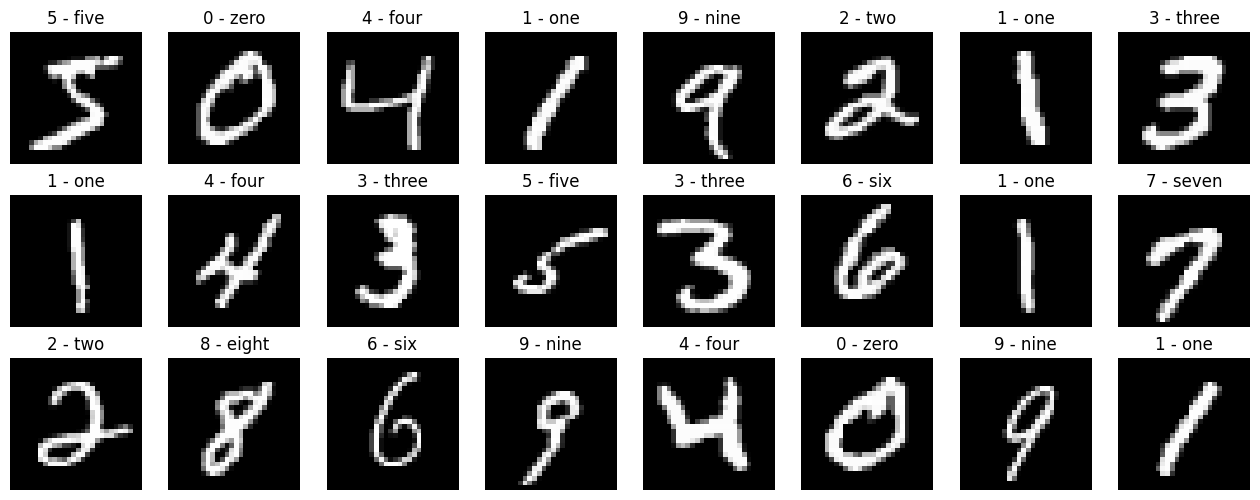

<Figure size 640x480 with 0 Axes>

In [47]:
images, targets = next(iter(train_loader))

# these are the transformed images
vcpi_util.show_transformed_images(3,8, train_set, train_set.classes) 

## Generator

Building the Generator ($G$)

The goal of the Generator is to take a seed of random noise and map it to the visual data space, creating images that resemble the training set.

How it works:

1. The Input: The network receives a 1D latent vector ($z$) sampled from a normal distribution.

1. Spatial Reshaping: This 1D vector is reshaped into a 1x1 spatial tensor with a depth (channels) equal to the latent space dimension. You can think of this as a tiny, dense "1-pixel" image with many feature channels.

1. Fractional-Strided Convolutions: To grow this 1x1 tensor into a full image, we use a sequence of Transpose Convolution layers (nn.ConvTranspose2d). Unlike standard convolutions that compress spatial dimensions, transpose convolutions upsample the spatial dimensions (height and width) while gradually decreasing the depth (channels).

1. Applying the DCGAN Rules: Following the guidelines from Radford et al., we apply Batch Normalization (nn.BatchNorm2d) and a ReLU activation after every transpose convolution layer, except the very last one.

1. The Output: The final transpose convolution layer outputs a tensor that exactly matches the target image dimensions (for MNIST, this is a 28x28 spatial grid with 1 color channel). As discussed, we apply a Tanh activation here to map all pixel values to the $[-1, 1]$ range.

In [48]:
class Generator(nn.Module):

    def __init__(self, latent_dim = 16):
        super().__init__()

        self.model = nn.Sequential(
            # (batch_size, latent_dim, 1, 1)

            nn.ConvTranspose2d(latent_dim, 128, kernel_size=7, stride=1, padding=0, bias=False),
            # (batch_size, 128, 7, 7)

            nn.BatchNorm2d(128),
            nn.ReLU(True),

            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1, bias=False),
            # (batch_size, 64, 14, 14)
            
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            nn.ConvTranspose2d(64, 1, kernel_size=4, stride=2, padding=1, bias=False),

            # (batch_size, 1, 28, 28)
            nn.Tanh()
        )

    def forward(self, z):
        # z shape: (batch_size, latent_dim)
        # # Reshapes (batch, latent_dim) to (batch, latent_dim, 1, 1)
        z = z.unsqueeze(-1).unsqueeze(-1)  
        img = self.model(z)
        return img  # shape: (batch_size, 1, 28, 28)

In [49]:
G = Generator(LATENT_SPACE_DIM)
G.to(device)

torchinfo.summary(G, input_size = (BATCH_SIZE, LATENT_SPACE_DIM),
                                     col_names=["kernel_size", "input_size", "output_size", "num_params", "mult_adds"])

Layer (type:depth-idx)                   Kernel Shape              Input Shape               Output Shape              Param #                   Mult-Adds
Generator                                --                        [32, 16]                  [32, 1, 28, 28]           --                        --
├─Sequential: 1-1                        --                        [32, 16, 1, 1]            [32, 1, 28, 28]           --                        --
│    └─ConvTranspose2d: 2-1              [7, 7]                    [32, 16, 1, 1]            [32, 128, 7, 7]           100,352                   157,351,936
│    └─BatchNorm2d: 2-2                  --                        [32, 128, 7, 7]           [32, 128, 7, 7]           256                       8,192
│    └─ReLU: 2-3                         --                        [32, 128, 7, 7]           [32, 128, 7, 7]           --                        --
│    └─ConvTranspose2d: 2-4              [4, 4]                    [32, 128, 7, 7]           

Feeding a random noise vector to an untrained Generator should provide an output that looks like random noise.

Generator outptu shape:  torch.Size([32, 1, 28, 28])


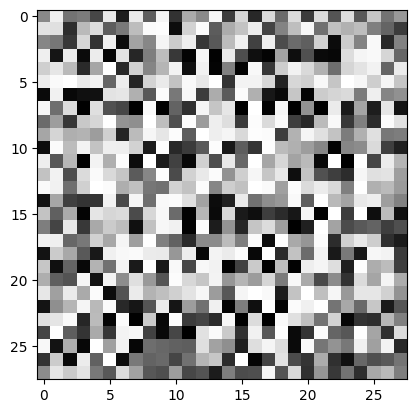

In [50]:
noise = torch.randn(BATCH_SIZE, LATENT_SPACE_DIM, device=device)

with torch.no_grad():
    out = G(noise)

print("Generator outptu shape: ", out.shape)

# shift the [-1, 1] range back to [0, 1] for matplotlib using: (out * 0.5) + 0.5
out_normalized = (out.detach().cpu() * 0.5) + 0.5

# show the output for the first image of the batch
plt.imshow(np.transpose(out_normalized[0].numpy() * 0.5 + 0.5, (1,2,0)), cmap='gray')

## Discriminator

Building the Discriminator ($D$)
The goal of the Discriminator is to act as our Art Detective. It must distinguish between genuine images from the training set and fake images produced by the Generator.

How it works:

1. The Input: The Discriminator takes a full 2D image as input (for MNIST, a $28 \times 28$ image with 1 color channel).

1. Strided Convolutions: Instead of using MaxPool2d layers to shrink the image, the DCGAN architecture uses Strided Convolutions (nn.Conv2d with stride=2). This forces the network to learn its own custom spatial downsampling (pooling) function.

1. Applying the DCGAN Rules: Following the guidelines from Radford et al., we apply Batch Normalization (nn.BatchNorm2d) and a LeakyReLU activation after the convolutional layers. LeakyReLU helps prevent the "dying ReLU" problem, ensuring gradients keep flowing back to the Generator even when the Discriminator is very confident.

1. The Output: The final layer collapses the spatial dimensions into a single scalar value. We apply a Sigmoid activation function here to squash this raw number into a valid probability between 0.0 (100% fake) and 1.0 (100% real).



In [51]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            # Input: (batch_size, 1, 28, 28)
            nn.Conv2d(1, 64, kernel_size=4, stride=2, padding=1, bias=True),
            # No batchnorm in first layer (DCGAN rule)
            nn.LeakyReLU(0.2, inplace=True),
            # Output: (batch_size, 64, 14, 14)

            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            # Output: (batch_size, 128, 7, 7)

            # Fully Convolutional Output (Crush 7x7 down to 1x1)
            nn.Conv2d(128, 1, kernel_size=7, stride=1, padding=0, bias=False),
            # Output: (batch_size, 1, 1, 1)
            
            # Note: We omit nn.Sigmoid() here to use BCEWithLogitsLoss during training
            # for better numerical stability.
        )

    def forward(self, x):
        # Pass through model
        out = self.model(x)
        # Squeeze the spatial dimensions: (batch_size, 1, 1, 1) -> (batch_size, 1)
        return out.view(-1, 1)

In [52]:
D = Discriminator()
D.to(device)

torchinfo.summary(D, input_size = (BATCH_SIZE, 1,28,28),
                                     col_names=["kernel_size", "input_size", "output_size", "num_params", "mult_adds"])

Layer (type:depth-idx)                   Kernel Shape              Input Shape               Output Shape              Param #                   Mult-Adds
Discriminator                            --                        [32, 1, 28, 28]           [32, 1]                   --                        --
├─Sequential: 1-1                        --                        [32, 1, 28, 28]           [32, 1, 1, 1]             --                        --
│    └─Conv2d: 2-1                       [4, 4]                    [32, 1, 28, 28]           [32, 64, 14, 14]          1,088                     6,823,936
│    └─LeakyReLU: 2-2                    --                        [32, 64, 14, 14]          [32, 64, 14, 14]          --                        --
│    └─Conv2d: 2-3                       [4, 4]                    [32, 64, 14, 14]          [32, 128, 7, 7]           131,072                   205,520,896
│    └─BatchNorm2d: 2-4                  --                        [32, 128, 7, 7]       

Because our Discriminator outputs raw logits (to be used with BCEWithLogitsLoss), feeding an image to an untrained network should result in an output near 0.0. (If we passed this 0.0 through a Sigmoid function, it would become 0.5, representing a 50% guess).

In [53]:
# Pass the batch of fake images we generated earlier into the Discriminator
with torch.no_grad():
    res = D(out)

print(f"Output shape: {res.shape}")
print(f"First 5 raw logit predictions: \n{res[:5]}") # Should be values near 0.0

Output shape: torch.Size([32, 1])
First 5 raw logit predictions: 
tensor([[-0.0285],
        [-0.2520],
        [-0.1982],
        [ 0.0076],
        [ 0.3077]], device='cuda:0')


## Building the GAN components

In the 2015 paper, Radford et al. specifically noted that for DCGANs to train stably:

"All weights were initialized from a zero-centered Normal distribution with standard deviation 0.02."

In [54]:
def weights_init(m):
    """
    Custom weight initialization for DCGANs as specified by Radford et al. (2015).
    Applies N(0, 0.02) to Convolutional and Transpose Convolutional layers.
    """
    classname = m.__class__.__name__
    
    # If the layer is a Convolution or Transpose Convolution
    if classname.find('Conv') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
        
    # If the layer is Batch Normalization
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

### Instantiating the Networks and Applying Initializations

With our architectures defined and our custom weight initialization function ready, we can now instantiate the Generator ($G$) and the Discriminator ($D$).

Here, we will:

1. Create instances of both models and move them to our compute device (GPU/CPU).

1. Use PyTorch's .apply() method, which recursively walks through every layer of a model and applies the custom weights_init function we just wrote. This ensures our networks start from the precise mathematical state required by the DCGAN architecture.

In [55]:
# 1. Instantiate the models
G = Generator(LATENT_SPACE_DIM).to(device)
D = Discriminator().to(device)

# 2. Apply the DCGAN weight initialization
G.apply(weights_init)
D.apply(weights_init)

print("Generator and Discriminator instantiated and weights initialized!")

Generator and Discriminator instantiated and weights initialized!


### Loss Function and Optimizers

To train our networks, we need a loss function to measure how well the Discriminator is classifying real vs. fake images, and optimizers to update the weights.

**DCGAN Optimizer tunning:**

GANs are notoriously unstable to train. The authors of DCGAN found that using standard Adam optimizer parameters caused the networks to oscillate and collapse. To fix this, they introduced two strict rules for the optimizers:

1. Lower the learning rate to 0.0002.

2. Lower the momentum ($\beta_1$) from PyTorch's default of 0.9 down to 0.5.

In [56]:
# 1. Define the Loss Function 
loss_fn = torch.nn.BCEWithLogitsLoss() 

# 2. Define the Labels for the Binary Cross Entropy
real_label = 1.0
fake_label = 0.0

# 3. Setup the Optimizers using the exact DCGAN hyperparameters
lr = 0.0002
beta1 = 0.5

optim_D = torch.optim.Adam(D.parameters(), lr=lr, betas=(beta1, 0.999))
optim_G = torch.optim.Adam(G.parameters(), lr=lr, betas=(beta1, 0.999))


## Training

Each epoch is a two stage process:

- Train the discriminator
- Train the generator

### Discriminator Training: 

The **Discriminator** is trained on:

- A batch of real images from the dataset, with labels set to 1 (real)
- A batch of fake images generated by the Generator, with labels set to 0 (fake).

The **Discriminator** aims to maximize:

$$ log(D(x))+log(1−D(G(z)))$$

where 

- $x$ is a real image
- $G(z)$ is a fake image produced by the Generator from random noise $z$

Code wise, this corresponds to using the BCE Loss with real labels (1) for real images, and fake labels (0) for fake images

### Generator Training: 

The **generator** is trained on a batch of latent vectors $z$, with the  goal of making the discriminator classify the produced images as real (labels set to 1). 

The **generator** aims to maximize:

$$ log (D(G(z))) $$

Because we want the Discriminator to output a 1.0 (real) for these fake images, we simply use our BCELoss function and set the target labels to 1.0. Just like in a standard CNN, minimizing this loss updates the Generator's weights to push the Discriminator's prediction closer to our target of 1.

(Historical Note: In the original 2014 GAN paper, this was formulated strictly as a Minimax game where the Generator minimized $1 - D(G(z))$. However, researchers quickly realized that simply maximizing $D(G(z))$—which is what happens when we set the PyTorch target to 1—provides much healthier gradients and prevents training from stalling. Today, this "non-saturating" approach is the standard).



### Common GAN issues

Training GANs can be difficult because the generator and discriminator must improve together; if one of them becomes too strong, learning can become unstable. The most common problems are:

* **Vanishing Gradients**: In the original GAN formulation, if the discriminator becomes very good at separating real and fake samples, the generator may receive gradients that are too small to provide a useful learning signal. In practice, this means that the generator stops improving even though training is still running.

* **Mode Collapse**: Instead of learning the full data distribution, the generator may discover a small set of outputs that reliably fool the discriminator and keep producing only those samples. On MNIST, this could appear as generating only a few digit styles, or overproducing some digits while ignoring others.

These issues are some of the main reasons why GANs are often considered harder to train than many other generative models. They also motivate the use of evaluation metrics that look not only at image quality, but also at diversity and distributional similarity.

In [57]:
def train_gan(
    G,
    D,
    train_loader,
    optimG,
    optimD,
    lossfn,
    latent_dim,
    epochs=30,
    save_prefix=None,
):
    G.train()
    D.train()
    G.to(device)
    D.to(device)

    latent_vis = torch.randn(64, latent_dim, device=device)

    history = {
        "D_loss": [],
        "G_loss": [],
    }

    for epoch in range(epochs):
        epoch_d_loss = 0.0
        epoch_g_loss = 0.0

        for i, (digits, _) in tqdm(enumerate(train_loader)):
            digits = digits.to(device)
            bsz = digits.size(0)

            # -------------------------
            # 1) Train Discriminator
            # -------------------------
            optimD.zero_grad()

            # Real batch
            real_targets = torch.full((bsz,), real_label, dtype=torch.float, device=device)
            out_real = D(digits).view(-1)
            errD_real = lossfn(out_real, real_targets)

            # Fake batch
            z = torch.randn(bsz, latent_dim, device=device)
            fake_images = G(z)
            fake_targets = torch.full((bsz,), fake_label, dtype=torch.float, device=device)
            out_fake = D(fake_images.detach()).view(-1)
            errD_fake = lossfn(out_fake, fake_targets)

            errD = errD_real + errD_fake
            errD.backward()
            optimD.step()

            # -------------------------
            # 2) Train Generator
            # -------------------------
            optimG.zero_grad()

            # Recompute discriminator output without detach so gradients flow to G
            real_targets = torch.full((bsz,), real_label, dtype=torch.float, device=device)
            out_gen = D(fake_images).view(-1)
            errG = lossfn(out_gen, real_targets)

            errG.backward()
            optimG.step()

            epoch_d_loss += errD.item()
            epoch_g_loss += errG.item()

            #print(
            #    f"epoch {epoch:03d}  batch {i:04d}/{len(train_loader):04d}  "
            #    f"D {errD.item():.4f}  G {errG.item():.4f}"
            #)

        history["D_loss"].append(epoch_d_loss / len(train_loader))
        history["G_loss"].append(epoch_g_loss / len(train_loader))

        if (epoch % 5 == 0) or (epoch == epochs - 1):
            G.eval()
            with torch.no_grad():
                fake_vis = G(latent_vis).detach().cpu()
                grid = torchvision.utils.make_grid(fake_vis, padding=2, normalize=True)
                plt.figure(figsize=(8, 8))
                plt.imshow(np.transpose(grid, (1, 2, 0)), cmap="gray")
                plt.axis("off")
                plt.show()
            G.train()

        if save_prefix is not None:
            torch.save(
                {
                    "epoch": epoch,
                    "generator": G.state_dict(),
                    "optimG": optimG.state_dict(),
                    "discriminator": D.state_dict(),
                    "optimD": optimD.state_dict(),
                    "history": history,
                },
                f"{save_prefix}_{latent_dim}_{epoch}.pt",
            )

    return history

In [58]:
if TRAIN:

    print("Starting Training")

    os.makedirs("gan_models_mnist", exist_ok=True)

    EPOCHS = 20

    history = train_gan(
        G=G,
        D=D,
        train_loader=train_loader,
        optimG=optim_G,
        optimD=optim_D,
        lossfn=loss_fn,
        latent_dim=LATENT_SPACE_DIM,
        epochs=EPOCHS,
        save_prefix="gan_models_mnist/gan_models_mnist"
    )

Load the model

In [59]:
import os

# Define the path to your saved checkpoint
# Update this string to match the actual file name saved by the training loop!
checkpoint_path = "gan_models_mnist/gan_models_mnist_16_29.pt" 

D, G = load(checkpoint_path)


Loading checkpoint from gan_models_mnist/gan_models_mnist_16_29.pt...
Successfully loaded! Model trained for 30 epochs.


# Evaluating the Generator

Once training is complete, we need to assess how good the generator actually is at producing realistic samples. In previous chapters this was straightforward: for classifiers we used accuracy on a labeled test set, and for autoencoders we used reconstruction error between input and output. For a GAN generator there is no ground-truth “label” or target image for each sample, so neither classification accuracy nor per-image reconstruction loss directly tells us how realistic the generated distribution is.

Qualitative visual inspection is a natural first step: looking at grids of generated images quickly reveals mode collapse, artifacts, or obvious failures that a single number might hide. However, visual checks alone are subjective and make it hard to compare models, hyperparameters, or training runs in a rigorous way. To obtain more objective and reproducible comparisons, we therefore turn to distribution-based metrics such as Fréchet Inception Distance (FID), Kernel Inception Distance (KID), and Sliced FID (SFID), which compare statistics of real and fake samples in a feature space defined by a classifier or embedding network instead of relying on labels or one-to-one reconstructions.

## Visual Inspection

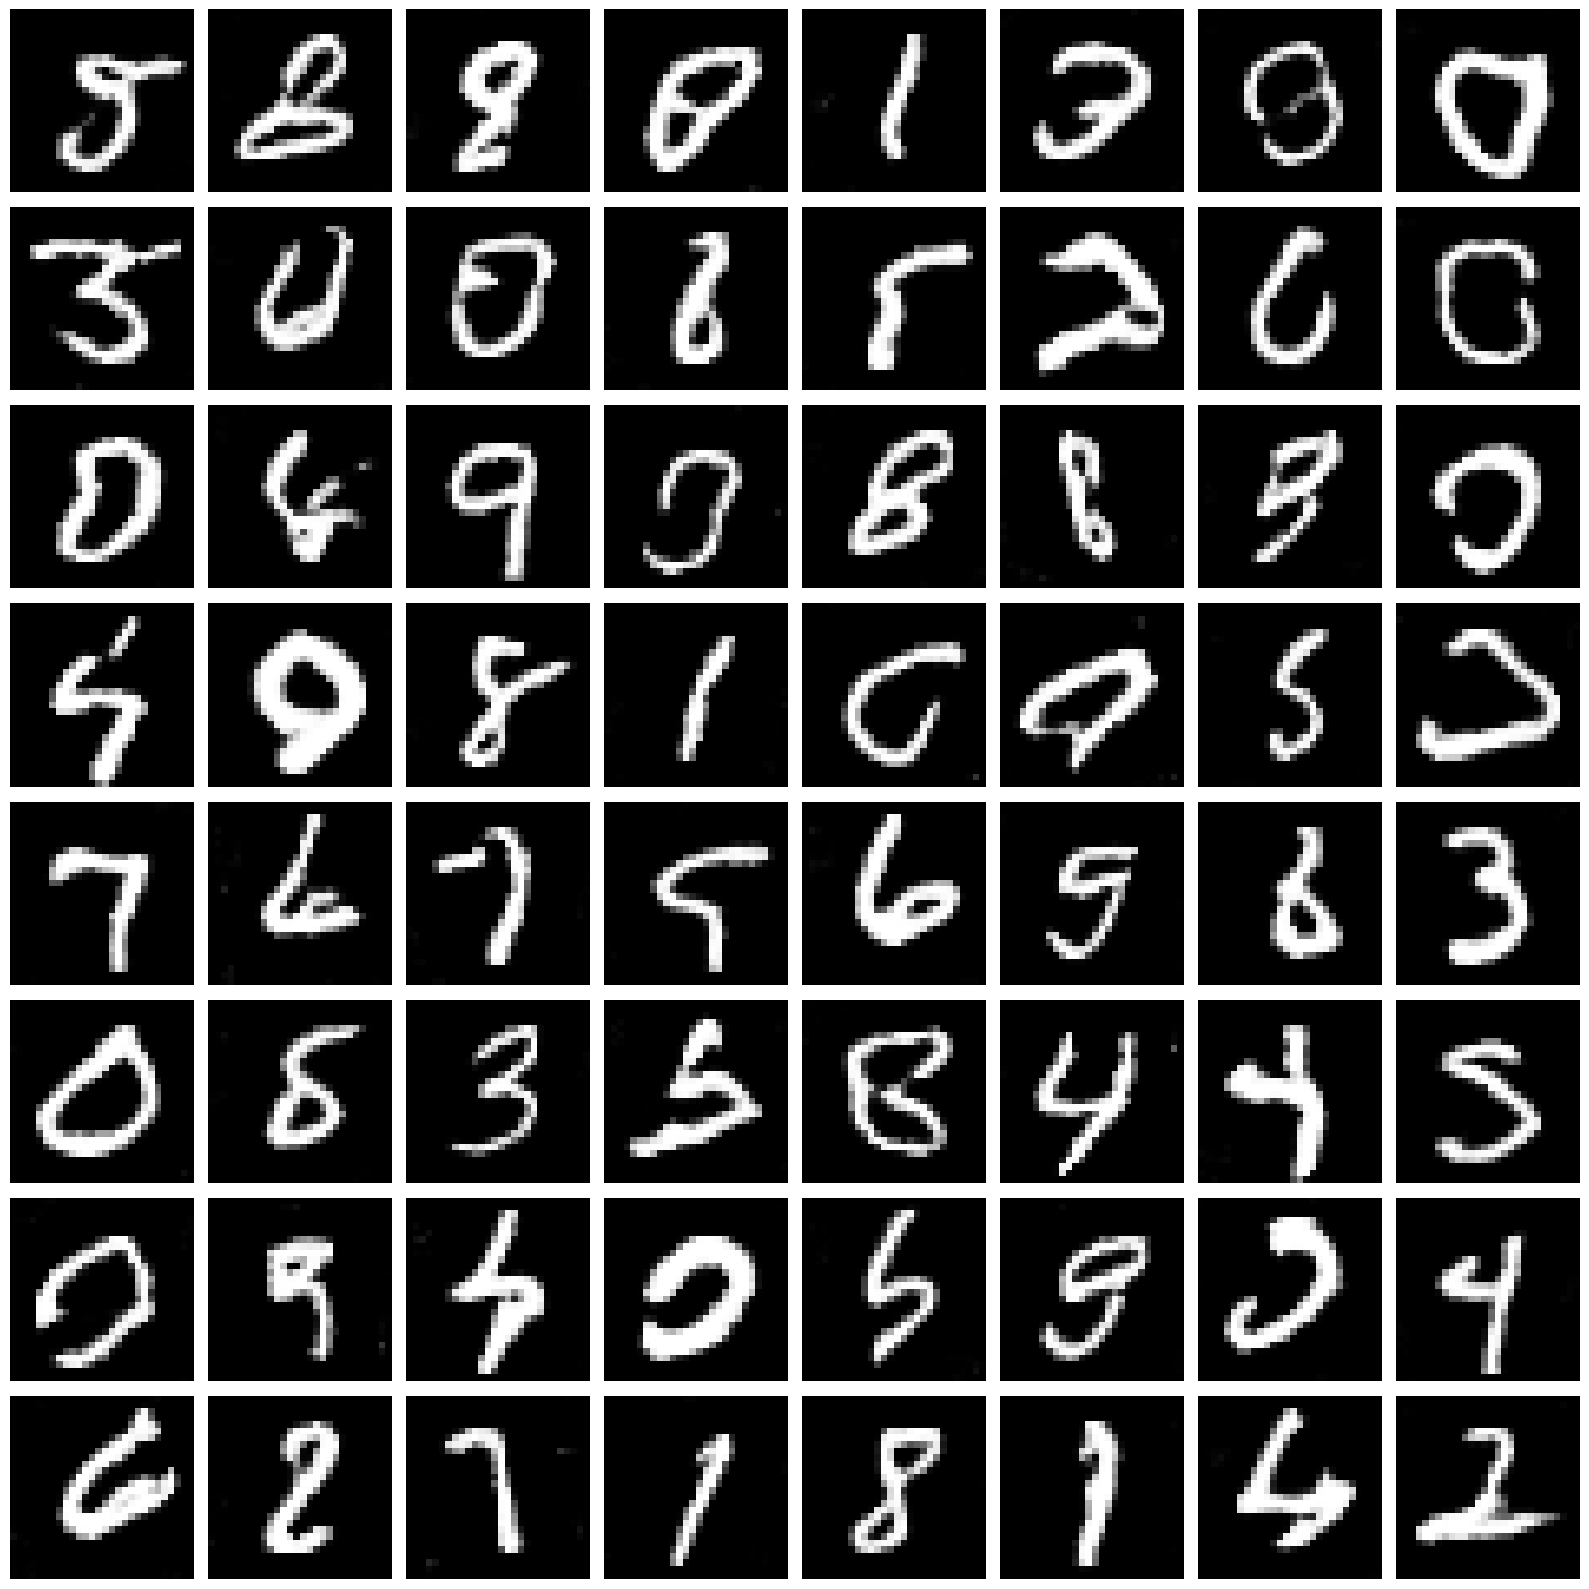

In [60]:
def show_gan_samples_simple(G, latent_dim, device, rows=8, cols=8):
    G.eval()
    with torch.no_grad():
        z = torch.randn(rows * cols, latent_dim, device=device)
        fake = G(z).cpu()  # [N, C, H, W]
    G.train()
    show_images(rows, cols, fake)  # your existing helper


show_gan_samples_simple(G, LATENT_SPACE_DIM, device)    

## Inception Score

### Evaluating our Generator: The Intuition

We have trained our Generator to draw MNIST digits, and it looks good upon visual inspection. But how do we prove that it's doing a good job?

Conveniently, we already have a tool that is an expert at looking at digits: a pre-trained mnist_classifier from previous notebooks! Since this classifier scores 99% accuracy on real digits, we can use it as an automated *judge* for our fake digits.

To evaluate the Generator we are going to subject it to distinct tests:

Image Clarity (Fidelity): When we show the judge a single generated image, it shouldn't be confused. If the Generator draws a blurry blob, the judge might say, "I'm 40% sure it's an 8, and 30% sure it's a 3." But if the Generator draws a crisp, realistic digit, the judge will be highly confident: "I am 99% sure this is a 7." We want our Generator to produce images that make the judge highly confident.

Batch Diversity: What if the Generator just memorizes how to draw one single, perfect '7' and draws it over and over again? The judge would be 99% confident every time, but the Generator has still failed (this is called Mode Collapse). To catch this, we need to look at a large batch of images. A good Generator should draw an equal mix of all 10 digits.

Let's test these two properties one by one, starting with Image Clarity. We'll generate a small batch of images, ask the judge to classify them, and see how confident it is!

### Step 1. Evaluating Image Clarity



In [61]:
class Conv_II(torch.nn.Module):

    def __init__(self, num_classes):
        super().__init__()
        
        # Block 1
        self.conv1 = torch.nn.Conv2d(1, 16, 3)
        self.bn1 = torch.nn.BatchNorm2d(16)
        self.relu1 = torch.nn.ReLU()
        
        self.conv2 = torch.nn.Conv2d(16, 32, 3)
        self.bn2 = torch.nn.BatchNorm2d(32)
        self.relu2 = torch.nn.ReLU()
        
        self.maxpool1 = torch.nn.MaxPool2d(2)

        # Block 2
        self.conv3 = torch.nn.Conv2d(32, 48, 3)
        self.bn3 = torch.nn.BatchNorm2d(48)
        self.relu3 = torch.nn.ReLU()
        
        self.conv4 = torch.nn.Conv2d(48, 48, 3)
        self.bn4 = torch.nn.BatchNorm2d(48)
        self.relu4 = torch.nn.ReLU()
        
        self.maxpool2 = torch.nn.MaxPool2d(2)
    
        # Dropout (p=0.5 drops 50% of the neurons randomly during training)
        self.dropout = torch.nn.Dropout(p=0.5)

        # Fully Connected (GAP outputs 48 channels as scalars -> 48 inputs)
        self.fc1 = torch.nn.Linear(48, num_classes)
        

    def forward(self, x):    
        
        x = self.conv1(x)       
        x = self.bn1(x)
        x = self.relu1(x)
        
        x = self.conv2(x)       
        x = self.bn2(x)
        x = self.relu2(x)
        
        x = self.maxpool1(x)    
        
        x = self.conv3(x)       
        x = self.bn3(x)
        x = self.relu3(x)
        
        x = self.conv4(x)       
        x = self.bn4(x)
        x = self.relu4(x)
        
        x = self.maxpool2(x)    
        
        # Apply GAP using torch.mean
        x = torch.mean(x, dim=[2, 3])   
        
        # Apply Dropout
        x = self.dropout(x)
        
        # Classifier
        x = self.fc1(x)        

        return x

In [62]:
# 1. Load your pre-trained MNIST classifier (Assuming you defined this earlier)
mnist_classifier = Conv_II(10).to(device)
reload = torch.load('model_conv_bn_mp.pt')
mnist_classifier.load_state_dict(reload['model'])



<All keys matched successfully>

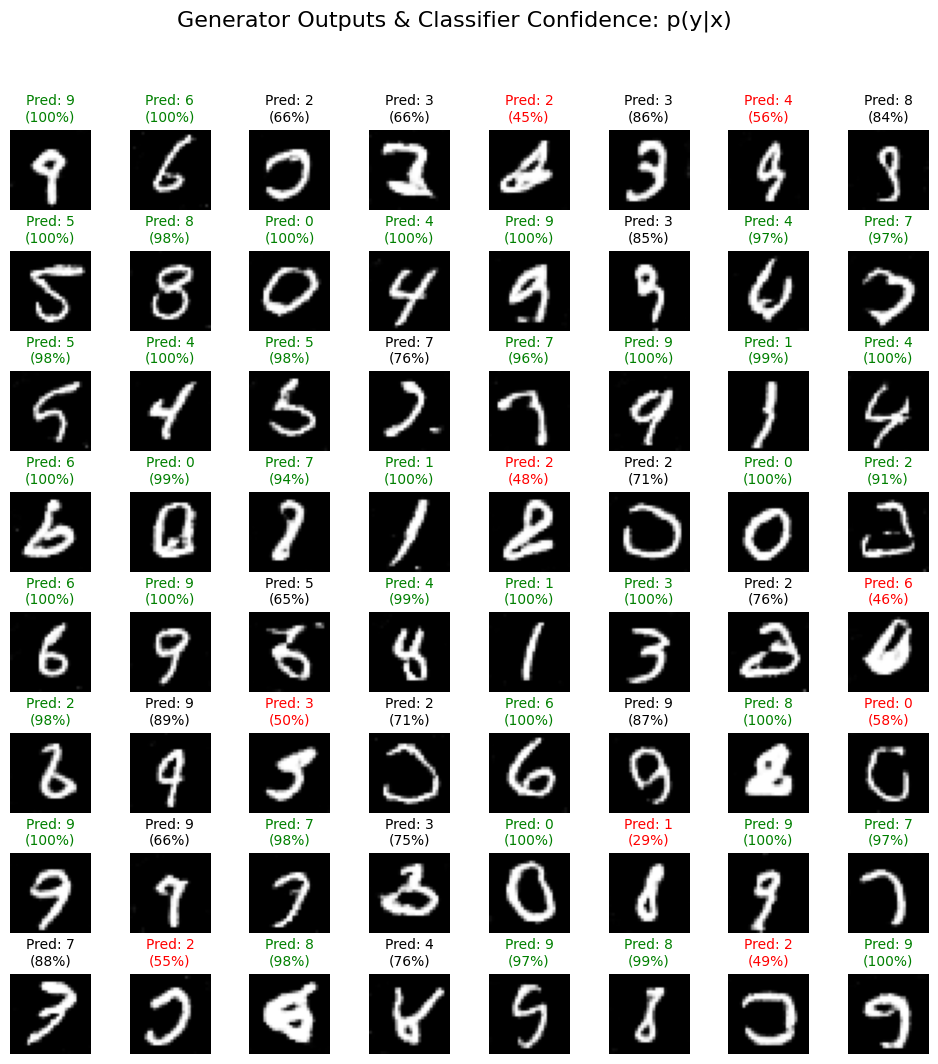

In [63]:
G.eval()
mnist_classifier.eval()

with torch.no_grad():
    # 1. Generate 64 fake images
    z = torch.randn(64, LATENT_SPACE_DIM, device=device)
    fake_imgs = G(z)  # Shape: (64, 1, 28, 28)
    
    # 2. Get predictions from our custom classifier
    logits = mnist_classifier((fake_imgs * 0.5) + 0.5)
    
    # 3. Convert raw logits to probabilities: p(y|x)
    p_yx = torch.nn.functional.softmax(logits, dim=1)
    
    # Extract the highest probability (confidence) and the predicted class
    confidences, predictions = torch.max(p_yx, dim=1)

# --- Plotting the Results ---
fig, axes = plt.subplots(8, 8, figsize=(12, 12))
fig.subplots_adjust(hspace=0.5, wspace=0.3)

# Move tensors to CPU for plotting
fake_imgs_cpu = fake_imgs.cpu()
predictions_cpu = predictions.cpu()
confidences_cpu = confidences.cpu()

for i, ax in enumerate(axes.flatten()):
    # Denormalize image from [-1, 1] to [0, 1] so Matplotlib displays it correctly
    img = (fake_imgs_cpu[i].squeeze() * 0.5) + 0.5
    
    ax.imshow(img, cmap='gray')
    ax.axis('off')
    
    # Title shows predicted digit and confidence percentage
    pred_label = predictions_cpu[i].item()
    conf = confidences_cpu[i].item() * 100
    
    # Color the text: Green if highly confident (>90%), Red if confused (<60%)
    color = "green" if conf > 90 else ("red" if conf < 60 else "black")
    ax.set_title(f"Pred: {pred_label}\n({conf:.0f}%)", fontsize=10, color=color)

plt.suptitle("Generator Outputs & Classifier Confidence: p(y|x)", fontsize=16)
plt.show()

The model seems pretty confident in most classifications which is a good indicator of the Generator's performance. 

Next we move on to test if the Generator is creating samples for every class.

### Step 2: Evaluating Batch Diversity

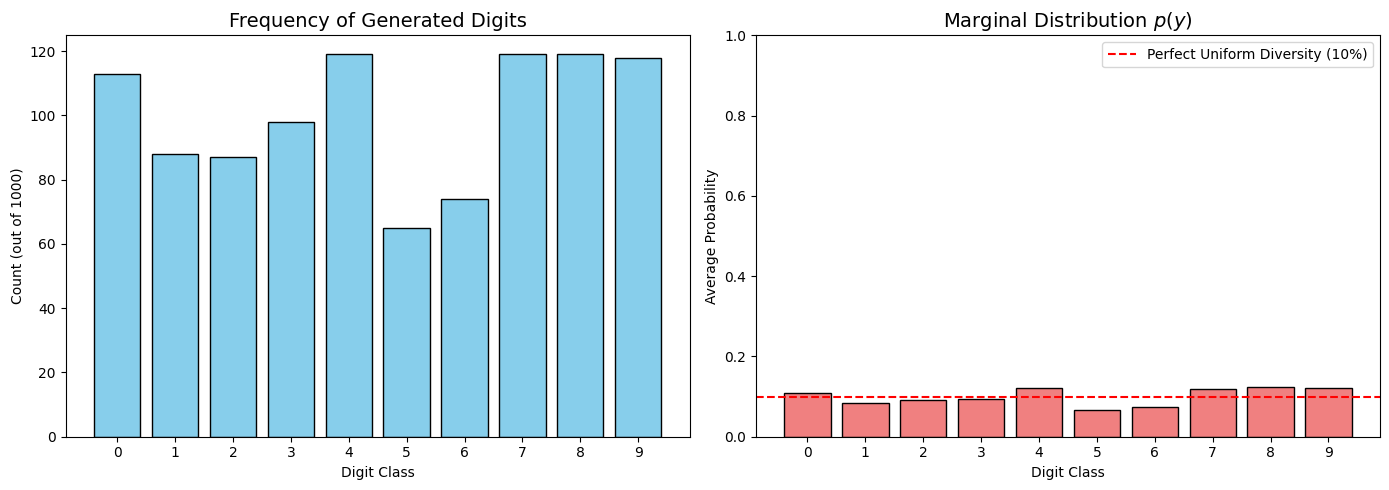

In [64]:
import matplotlib.pyplot as plt
import numpy as np

G.eval()
mnist_classifier.eval()

with torch.no_grad():
    # 1. Generate a large batch of 1000 fake images
    z = torch.randn(1000, LATENT_SPACE_DIM, device=device)
    fake_imgs = G(z)
    
    # 2. Denormalize images to [0, 1] for our custom classifier
    imgs_for_classifier = (fake_imgs * 0.5) + 0.5
    
    # 3. Get predictions
    logits = mnist_classifier(imgs_for_classifier)
    
    # 4. Convert to probabilities for each image: p(y|x)
    p_yx = torch.nn.functional.softmax(logits, dim=1)
    
    # 5. Calculate the Batch Average: p(y)
    # We take the mean across the batch dimension (dim=0)
    p_y = p_yx.mean(dim=0)
    
    # Also extract the hard predicted labels just for the histogram plot
    _, predictions = torch.max(p_yx, dim=1)

# --- Plotting the Results ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Histogram of Hard Predictions
ax1.hist(predictions.cpu().numpy(), bins=np.arange(11)-0.5, rwidth=0.8, color='skyblue', edgecolor='black')
ax1.set_xticks(range(10))
ax1.set_title("Frequency of Generated Digits", fontsize=14)
ax1.set_xlabel("Digit Class")
ax1.set_ylabel("Count (out of 1000)")

# Plot 2: The Marginal Distribution p(y)
ax2.bar(range(10), p_y.cpu().numpy(), color='lightcoral', edgecolor='black')
ax2.set_xticks(range(10))
ax2.set_ylim(0, 1.0)
# A perfectly uniform distribution is 10% (0.1) for each of the 10 classes
ax2.axhline(y=0.1, color='red', linestyle='--', label='Perfect Uniform Diversity (10%)')
ax2.set_title("Marginal Distribution $p(y)$", fontsize=14)
ax2.set_xlabel("Digit Class")
ax2.set_ylabel("Average Probability")
ax2.legend()

plt.tight_layout()
plt.show()

### Step 3: Turning our observations into a single score

So far, we have checked two things:

1. For each individual image, the classifier is usually very confident about which digit it sees. That tells us the images are clear and recognizable.

2. Across a large batch, the classifier predicts all 10 digits with roughly equal frequency. That tells us the Generator is not collapsing onto a single digit and is producing a diverse set of samples.

Intuitively, a “good” Generator is one that:

* Produces images that look like some specific digit (high confidence per image).

* Produces all digits over time (balanced usage of classes).

Now we need a way to summarize both of these behaviors with a single number. A higher number should mean “images are clearer and more diverse,” while a lower number should mean “images are blurry, repetitive, or both.”
This is exactly what the Inception Score does.

In 2016, Salimans et al. proposed exactly such a metric when they introduced the **Inception Score** as a way to automatically evaluate GAN samples using a pre-trained classifier, instead of relying solely on visual inspection.

In the original work, they used an ImageNet-trained Inception-v3 network as the judge and showed that higher scores correlated well with human judgments of image quality and variety across datasets like CIFAR-10 and ImageNet.

Here we follow the same idea, but replace Inception-v3 with our own MNIST classifier so that the score is tailored to handwritten digits rather than natural images.



From intuition to formula
Mathematically, we already have everything we need:

$p(y∣x)$: For each generated image x, our classifier gives a probability distribution over the 10 digits. This captures how confident the classifier is for that image.

$p(y)$: If we average $p(y∣x)$ over many generated images, we get the overall class usage of the Generator. If the Generator uses all digits equally, $p(y)$ is close to uniform.

The **Inception Score** measures how different these two are:

* We want each $p(y∣x)$ to be peaked (one digit with high probability).

* We want the average $p(y)$ to be flat (all digits used).

To quantify this difference, we use the KL divergence between $p(y∣x)$ (per-image confidence) and p$(y)$ (batch-level usage):

$$ D_{KL}\big(p(y \mid x) \,||\, p(y)\big) = \sum_y p(y \mid x)\,\log\frac{p(y \mid x)}{p(y)}$$
We compute this for every generated image, average over the batch, and then apply an exponential:

$$ IS=exp(E_x [D_{KL}(p(y∣x)∣∣p(y))]) $$

Because our classifier has 10 classes, the best possible score is 10.0.
Let’s now compute this quantity directly for our Generator.

### Reference:

Improved Techniques for Training GANs, Tim Salimans, Ian Goodfellow, Wojciech Zaremba, Vicki Cheung, Alec Radford, Xi Chen [PDF](https://arxiv.org/pdf/1606.03498)


In [65]:
import torch
import torch.nn.functional as F

G.eval()
mnist_classifier.eval()

with torch.no_grad():
    # 1. Generate 1000 fake images
    z = torch.randn(1000, LATENT_SPACE_DIM, device=device)
    fake_imgs = G(z)
    
    # 2. Denormalize images to [0, 1] BEFORE passing them in!
    imgs_for_classifier = (fake_imgs * 0.5) + 0.5
    
    # 3. Get predictions
    logits = mnist_classifier(imgs_for_classifier)
    
    # 4. Calculate p(y|x) - Image Clarity
    # Shape: (1000, 10)
    p_yx = F.softmax(logits, dim=1)
    
    # 5. Calculate p(y) - Batch Diversity
    # We keepdim=True so it remains (1, 10) for broadcasting later
    p_y = p_yx.mean(dim=0, keepdim=True)
    
    # 6. Calculate KL Divergence
    # We add a tiny epsilon (1e-16) to prevent log(0) errors 
    # if the classifier is 100% confident
    kl_d = p_yx * (torch.log(p_yx + 1e-16) - torch.log(p_y + 1e-16))

    # Sum over classes y  -> Σ_y p(y|x) log(p(y|x)/p(y))  for each image
    kl_per_image = kl_d.sum(dim=1)          # shape: (N,)

    # Average over images x ->  E_x[ D_KL( p(y|x) || p(y) ) ]
    kl_mean = kl_per_image.mean()

    # Apply the exponential to get the final Inception Score
    is_score = torch.exp(kl_mean)
    
    print(f"Custom MNIST Inception Score: {is_score.item():.4f} / 10.0")

Custom MNIST Inception Score: 7.5825 / 10.0


A score of $7.8573$ out of a theoretical maximum of $10$ is a strong result for an unconditional DCGAN on MNIST.

It tells you that:

* The classifier is usually very confident on individual generated digits (so samples are sharp and recognizable), and

* The Generator is using most or all of the 10 classes in a reasonably balanced way (no obvious mode collapse).

In other words, **relative to the MNIST classifier** we used as the judge, the GAN is already in the “high-quality, high-diversity” regime.

## Feature Based metrics.

The next metrics evaluate the Generator by looking at the feature vectors produced by a convolutional network, rather than the raw pixel values. They compare the feature distributions of fake (generated) images to those of real MNIST images using different statistical strategies.

In the original definitions, these methods use features extracted from a pre‑trained Inception network trained on ImageNet. Because MNIST digits do not resemble natural images, and to keep the evaluation aligned with our task, we will instead use our own MNIST classifier as the feature extractor. Concretely, we take the 48‑dimensional vector from the global average pooling layer as the feature representation for each image.

By implementing these metrics ourselves in this custom feature space, we gain deeper insight into what they are actually measuring and how they behave in practice. 

First, we create a subclass of our classifier that exposes a forward_features method returning the 48‑dimensional feature vector. We will also add a date loader for the real images. Then we will define FID, KID, and SFID directly on top of those features.

In [66]:
class ConvIIWithFeatures(Conv_II):
    def forward_features(self, x):
        # x: (N, 1, 28, 28) in [0,1]
        x = self.conv1(x)
        x = self.bn1(x); x = self.relu1(x)
        
        x = self.conv2(x)
        x = self.bn2(x); x = self.relu2(x)
        x = self.maxpool1(x)
        
        x = self.conv3(x)
        x = self.bn3(x); x = self.relu3(x)
        
        x = self.conv4(x)
        x = self.bn4(x); x = self.relu4(x)
        
        x = self.maxpool2(x)          # (N, 48, 5, 5)
        x = torch.mean(x, dim=[2, 3]) # (N, 48)
        return x
    
# Re-instantiate and load weights into the extended class
mnist_classifier = ConvIIWithFeatures(10).to(device)
reload = torch.load('model_conv_bn_mp.pt', map_location=device)
mnist_classifier.load_state_dict(reload['model'])
mnist_classifier.eval()

def get_features(model, imgs):

    with torch.no_grad():
        feats = model.forward_features(imgs)  # (N, D)
    return feats    

transform = transforms.Compose(
    [transforms.ToTensor()]) 

train_set = torchvision.datasets.MNIST(root='./data', train=True,
                                        download=True, transform=transform)
train_loader = torch.utils.data.DataLoader(train_set, batch_size=BATCH_SIZE,
                                          shuffle=True)


### Fréchet Inception Distance (FID) 

The Inception Score tells us that individual samples look clear and that the generator is using all digit classes, but it never checks how closely the overall distribution of fake images matches the distribution of real MNIST digits. To do that, we move from class probabilities to the internal feature vectors of our MNIST classifier: each real and fake image becomes a point in a 48‑dimensional feature space.

What we want to measure is whether the cloud of fake feature points sits in the same region of this space as the cloud of real feature points. If the generator is doing a good job, both clouds should have similar centers (similar “average” features) and a similar spread/shape (capturing the same variability in stroke thickness, style, rotations, etc.). If the fake cloud is shifted, squeezed, or missing parts of the real cloud, that means the generator is systematically off, even if individual samples look plausible.

FID formalizes this idea by fitting a Gaussian to the real features and another Gaussian to the fake features, then measuring how far apart these two Gaussians are. This makes sense because the final feature layer of a well‑trained classifier tends to organize similar digits into tight clusters; matching the means and covariances of those clusters is a compact way to match the overall data distribution. A perfect generator would produce fake features whose mean and covariance are identical to the real ones, giving FID = 0; larger FID values indicate larger distribution mismatches, even when the samples look sharp and diverse to the eye.

Mathematically, the FID score can be expressed as:
$$
\mathrm{FID}(X_r, X_g)
= \left\lVert \mu_r - \mu_g \right\rVert_2^2
+ \operatorname{Tr}\!\Big(
    \Sigma_r + \Sigma_g
    - 2 \big( \Sigma_r \Sigma_g \big)^{1/2}
  \Big).
$$

To compute the square root of a symmetric positive semidefinite matrix $A$, we first perform an eigendecomposition and then take square roots of the eigenvalues. For such matrices, the trace of $A^{1/2}$ equals the sum of the square roots of its eigenvalues.

$$
A = Q \Lambda Q^{\top}, \qquad
A^{1/2} = Q \Lambda^{1/2} Q^{\top},
$$

$$
\Lambda^{1/2} = \operatorname{diag}\!\big(\sqrt{\lambda_1}, \dots, \sqrt{\lambda_d}\big).
$$

$$
\operatorname{Tr}\!\big( A^{1/2} \big)
= \sum_{i=1}^d \sqrt{\lambda_i}.
$$

#### Reference

* GANs Trained by a Two Time-Scale Update Rule Converge to a Local Nash Equilibrium, Martin Heusel, Hubert Ramsauer, Thomas Unterthiner, Bernhard Nessler, Sepp Hochreiter [PDF](https://arxiv.org/abs/1706.08500)

In [67]:
def compute_mean_and_cov(feats: torch.Tensor):
    # feats: (N, D)
    mu = feats.mean(dim=0)                           # (D,)
    # rowvar=False → covariance over columns (features)
    xc = feats - mu
    # divide by N-1 for the unbiased estimator
    cov = xc.T @ xc / (feats.size(0) - 1)            # (D, D)
    return mu, cov

def frechet_distance(mu_r, cov_r, mu_g, cov_g):
    # All inputs: torch tensors on same device
    diff = mu_r - mu_g
    diff_sq = diff.dot(diff)

    # Compute sqrt of cov_r @ cov_g via eigen-decomposition
    cov_prod = cov_r @ cov_g
    # Symmetrize for numerical stability
    cov_prod = (cov_prod + cov_prod.T) * 0.5

    eigvals, _ = torch.linalg.eigh(cov_prod)
    # Clamp eigenvalues to avoid negative due to numerical issues
    eigvals = torch.clamp(eigvals, min=0)

    # Trace of the matrix square root is sum of sqrt eigenvalues
    tr_sqrt_cov_prod = eigvals.sqrt().sum()

    # compute FID
    trace_term = torch.trace(cov_r) + torch.trace(cov_g) - 2 * tr_sqrt_cov_prod
    fid = diff_sq + trace_term
    return fid


def compute_fid_from_features(real_feats, fake_feats):

    # 3. Compute mean and covariance (Gaussian fits in feature space)
    mu_r, cov_r = compute_mean_and_cov(real_feats)
    mu_g, cov_g = compute_mean_and_cov(fake_feats)

    # 4. Compute FID
    fid = frechet_distance(mu_r, cov_r, mu_g, cov_g)
    return fid

def compute_mnist_fid(G, classifier, train_loader, num_real=1000, num_fake=1000):
    G.eval()
    classifier.eval()

    # 1. Collect real features
    real_feats_list = []
    total = 0
    with torch.no_grad():
        for imgs, _ in train_loader:
            imgs = imgs.to(device)    # [0, 1] from data loader
            feats = get_features(classifier, imgs)
            real_feats_list.append(feats)
            total += imgs.size(0)
            if total >= num_real:
                break
    real_feats = torch.cat(real_feats_list, dim=0)[:num_real]

    # 2. Collect fake features
    fake_feats_list = []
    total = 0
    with torch.no_grad():
        while total < num_fake:
            bs = min(num_fake - total, train_loader.batch_size)
            z = torch.randn(bs, LATENT_SPACE_DIM, device=device)
            fake_imgs = G(z)                    # [-1, 1]
            fake_imgs = (fake_imgs * 0.5) + 0.5 # [0,1]
            feats = get_features(classifier, fake_imgs)
            fake_feats_list.append(feats)
            total += bs
    fake_feats = torch.cat(fake_feats_list, dim=0)[:num_fake]


    fid = compute_fid_from_features(real_feats, fake_feats)
    return fid.item()

In [68]:
mnist_fid = compute_mnist_fid(G, mnist_classifier, train_loader, num_real=1000, num_fake=1000)
print(f"Custom MNIST FID (Conv_II features): {mnist_fid:.4f}")

Custom MNIST FID (Conv_II features): 2.4907


In our setup (MNIST, 48‑D classifier features, 1k real / 1k fake samples), the generator achieves FID ≈ 2.26, suggesting a close match between real and generated feature distributions. Because FID is not an absolute metric and depends on the evaluation pipeline, this value is meaningful primarily for comparing models and training schemes within the same experimental conditions.

### Kernel Inception Distance (KID)

FID compares the real and fake feature clouds by assuming they can each be summarized well by a single Gaussian (a mean and covariance). That gives us a compact, global notion of “how different are these two distributions?”, but it may miss more subtle mismatches if the feature distributions are not close to Gaussian, or if we have relatively few samples.

With KID, we want to answer the same high‑level question—“Do the real and fake features behave the same way as a set?”—but without forcing them into a Gaussian shape. Instead of fitting parametric models, we look at how similar features are to each other under a flexible, nonlinear similarity function (a kernel). If we apply this kernel to all pairs of real features and all pairs of fake features, then mix real and fake together, a good generator should make those three patterns of similarities look the same; any systematic difference tells us the fake distribution is still distinguishable from the real one.

Kernel Inception Distance implements this idea using a polynomial kernel on the Conv_II feature vectors and the Maximum Mean Discrepancy (MMD) framework. This makes sense because MMD gives us a principled way to say “these two sets of points come from the same distribution” purely from kernel evaluations, without estimating densities or matrix square roots. If the generator perfectly matches the real feature distribution, KID goes to zero; the more the generator drifts away, the larger KID becomes, and it tends to behave more robustly than FID when we only have a modest number of samples.


$$ \mathrm{KID}(X,Y)
= \widehat{\mathrm{MMD}}^2_k(X,Y), $$

$$ \widehat{\mathrm{MMD}}^2_k(X,Y)
= \frac{1}{m(m-1)} \sum_{i \ne j} k(x_i, x_j)
+ \frac{1}{n(n-1)} \sum_{i \ne j} k(y_i, y_j)
- \frac{2}{mn} \sum_{i=1}^m \sum_{j=1}^n k(x_i, y_j), $$

where:
* $X=\{x_1 ,…, x_m \}$: features of real images.

* $Y=\{y_1 ,…, y_n \}$: features of fake images.

For KID we use the same kernel as in the original paper:

 $$ k(a,b) = \left( \frac{1}{d}\, a^\top b + 1 \right)^3, $$

where $d$ is the feature dimension. This kernel is essentially a normalized, shifted similarity between two feature vectors: it starts from the dot product $a^\top b$, scales it by $\frac{1}{d}$, adds a constant offset to keep it positive, and then applies a cubic nonlinearity. The choice of the cubic exponent is not theoretically unique; it is the convention adopted by the KID authors, and in principle other exponents or other kernels could be used, potentially working better for different feature extractors or data domains

#### Reference

Demystifying MMD GANs, Mikołaj Binkowski, Danica J. Sutherland, Michael Arbel & Arthur Gretton [PDF](https://arxiv.org/pdf/1801.01401)




In [69]:
def polynomial_kernel(x, y, degree=3, gamma=None, coef=1.0):
    # x: (N, D), y: (M, D)
    D = x.size(1)
    if gamma is None:
        gamma = 1.0 / D
    return (gamma * x @ y.T + coef) ** degree

def compute_kid_from_features(real_feats: torch.Tensor, fake_feats: torch.Tensor):
    # real_feats: (N_r, D), fake_feats: (N_g, D)
    K_rr = polynomial_kernel(real_feats, real_feats)   # (N_r, N_r)
    K_gg = polynomial_kernel(fake_feats, fake_feats)   # (N_g, N_g)
    K_rg = polynomial_kernel(real_feats, fake_feats)   # (N_r, N_g)

    m = real_feats.size(0)
    n = fake_feats.size(0)

    mmd2 = K_rr.mean() + K_gg.mean() - 2 * K_rg.mean()
    return mmd2.item()

def compute_mnist_kid(G, classifier, train_loader, num_real=1000, num_fake=1000):
    G.eval()
    classifier.eval()

    # Reuse the collection logic from FID
    real_feats_list = []
    total = 0
    with torch.no_grad():
        for imgs, _ in train_loader:
            imgs = imgs.to(device)
            feats = get_features(classifier, imgs)
            real_feats_list.append(feats)
            total += imgs.size(0)
            if total >= num_real:
                break
    real_feats = torch.cat(real_feats_list, dim=0)[:num_real]

    fake_feats_list = []
    total = 0
    with torch.no_grad():
        while total < num_fake:
            bs = min(num_fake - total, train_loader.batch_size)
            z = torch.randn(bs, LATENT_SPACE_DIM, device=device)
            fake_imgs = G(z)
            fake_imgs = (fake_imgs * 0.5) + 0.5 # [0,1]

            feats = get_features(classifier, fake_imgs)
            fake_feats_list.append(feats)
            total += bs
    fake_feats = torch.cat(fake_feats_list, dim=0)[:num_fake]

    kid = compute_kid_from_features(real_feats, fake_feats)
    return kid

In [70]:
mnist_kid = compute_mnist_kid(G, mnist_classifier, train_loader, num_real=1000, num_fake=1000)
print(f"Custom MNIST KID (Conv_II features, poly kernel): {mnist_kid:.6f}")

Custom MNIST KID (Conv_II features, poly kernel): 0.263433


### Sliced FID (SFID)

Both FID and KID look at the full 48‑dimensional feature space at once. That’s powerful, but it can be hard to build intuition for what a high or low number really means in such a high‑dimensional setting. With Sliced FID, we ask a slightly simpler question: “If I look at the real and fake distributions along many different one‑dimensional directions, do they still line up?”

The idea is to repeatedly pick a random direction in feature space, project all real and fake feature vectors onto that single line, and compare the resulting 1D distributions. Along any given direction, a good generator should produce projections with a similar average and spread as the real data; if there is a consistent shift or change in variance, that direction will register a larger 1D discrepancy. By averaging the 1D FID values over many such random slices, SFID captures how well the generator matches the real distribution from many different viewpoints, instead of relying on a single global Gaussian approximation. This makes SFID a useful geometric companion to FID and KID: lower SFID means that, in most directions, real and fake features overlap closely, while higher SFID reveals systematic mismatches that may not be obvious from a few sample images alone.


In [71]:
def compute_sfid_from_features(real_feats: torch.Tensor,
                               fake_feats: torch.Tensor,
                               num_projections: int = 256):
    # real_feats, fake_feats: (N, D)
    device = real_feats.device
    N_r, D = real_feats.shape
    N_g, _ = fake_feats.shape

    sfid_vals = []

    for _ in range(num_projections):
        # Random direction u ~ N(0,I), normalized
        u = torch.randn(D, device=device)
        u = u / (u.norm() + 1e-8)

        # Project to 1D
        r_proj = real_feats @ u  # (N_r,)
        g_proj = fake_feats @ u  # (N_g,)

        # Means and stds
        mu_r = r_proj.mean()
        mu_g = g_proj.mean()
        std_r = r_proj.std(unbiased=True)
        std_g = g_proj.std(unbiased=True)

        # 1D FID
        fid_1d = (mu_r - mu_g).pow(2) + (std_r - std_g).pow(2)
        sfid_vals.append(fid_1d)

    sfid = torch.stack(sfid_vals).mean()
    return sfid.item()

def compute_mnist_sfid(G, classifier, train_loader,
                       num_real=1000, num_fake=1000, num_projections=256):
    G.eval()
    classifier.eval()

    real_feats_list = []
    total = 0
    with torch.no_grad():
        for imgs, _ in train_loader:
            imgs = imgs.to(device)
            feats = get_features(classifier, imgs)
            real_feats_list.append(feats)
            total += imgs.size(0)
            if total >= num_real:
                break
    real_feats = torch.cat(real_feats_list, dim=0)[:num_real]

    fake_feats_list = []
    total = 0
    with torch.no_grad():
        while total < num_fake:
            bs = min(num_fake - total, train_loader.batch_size)
            z = torch.randn(bs, LATENT_SPACE_DIM, device=device)
            fake_imgs = G(z)
            fake_imgs = (fake_imgs * 0.5) + 0.5 # [0,1]
            feats = get_features(classifier, fake_imgs)
            fake_feats_list.append(feats)
            total += bs
    fake_feats = torch.cat(fake_feats_list, dim=0)[:num_fake]

    sfid = compute_sfid_from_features(real_feats, fake_feats, num_projections=num_projections)
    return sfid

In [72]:
mnist_sfid = compute_mnist_sfid(G, mnist_classifier, train_loader,
                                num_real=1000, num_fake=1000, num_projections=256)
print(f"Custom MNIST SFID (Conv_II features): {mnist_sfid:.4f}")

Custom MNIST SFID (Conv_II features): 0.0263


### Some more test (this section is WIP)

In [73]:
import torch
import pandas as pd

# ------------------------------------------------------------
# Feature extraction helpers
# ------------------------------------------------------------

@torch.no_grad()
def collect_real_features(classifier, loader, num_real):
    classifier.eval()

    feats_list = []
    total = 0

    for imgs, _ in loader:
        imgs = imgs.to(device)
        feats = get_features(classifier, imgs)
        feats_list.append(feats)
        total += imgs.size(0)

        if total >= num_real:
            break

    real_feats = torch.cat(feats_list, dim=0)[:num_real]
    return real_feats


@torch.no_grad()
def sample_fake_features(G, classifier, num_fake, batch_size):
    G.eval()
    classifier.eval()

    feats_list = []
    total = 0

    while total < num_fake:
        bs = min(num_fake - total, batch_size)
        z = torch.randn(bs, LATENT_SPACE_DIM, device=device)
        fake_imgs = G(z)
        fake_imgs = (fake_imgs * 0.5) + 0.5   # to [0,1], same as your SFID code
        feats = get_features(classifier, fake_imgs)
        feats_list.append(feats)
        total += bs

    fake_feats = torch.cat(feats_list, dim=0)[:num_fake]
    return fake_feats

@torch.no_grad()
def sample_fake_features_rotated(G, classifier, num_fake, batch_size):
    G.eval()
    classifier.eval()

    feats_list = []
    total = 0

    while total < num_fake:
        bs = min(num_fake - total, batch_size)
        z = torch.randn(bs, LATENT_SPACE_DIM, device=device)
        fake_imgs = G(z)                     # [-1,1] or whatever you use
        fake_imgs = (fake_imgs * 0.5) + 0.5  # to [0,1], same as before

        # Rotate by 90 degrees (k=1, counter-clockwise, for BCHW tensors)
        fake_imgs_rot = torch.rot90(fake_imgs, k=1, dims=(2, 3))

        feats = get_features(classifier, fake_imgs_rot)
        feats_list.append(feats)
        total += bs

    fake_feats = torch.cat(feats_list, dim=0)[:num_fake]
    return fake_feats
# ------------------------------------------------------------
# Metric wrappers from features
# ------------------------------------------------------------
# Replace these names if your notebook uses slightly different ones.

def metric_fid(real_feats, fake_feats):
    return compute_fid_from_features(real_feats, fake_feats)

def metric_kid(real_feats, fake_feats):
    return compute_kid_from_features(real_feats, fake_feats)

def metric_sfid(real_feats, fake_feats, num_projections=256):
    return compute_sfid_from_features(real_feats, fake_feats, num_projections=num_projections)


# ------------------------------------------------------------
# Robustness / sanity experiments
# ------------------------------------------------------------

def evaluate_metrics_on_pair(real_feats, other_feats, num_projections=256):
    return {
        "FID": float(metric_fid(real_feats, other_feats)),
        "KID": float(metric_kid(real_feats, other_feats)),
        "SFID": float(metric_sfid(real_feats, other_feats, num_projections=num_projections)),
    }


def run_metric_robustness_experiment(
    G,
    classifier,
    train_loader,
    num_real=1000,
    num_fake=1000,
    num_fake_repeats=3,
    num_projections=256,
):
    real_feats = collect_real_features(classifier, train_loader, num_real=num_real)

    # 1) Sanity check: real vs shuffled real
    perm = torch.randperm(real_feats.size(0), device=real_feats.device)
    real_feats_shuffled = real_feats[perm]
    sanity_scores = evaluate_metrics_on_pair(
        real_feats,
        real_feats_shuffled,
        num_projections=num_projections,
    )

    # 2) Robustness: real vs independently sampled fake sets
    fake_rows = []
    for run_idx in range(1, num_fake_repeats + 1):
        fake_feats = sample_fake_features(
            G,
            classifier,
            num_fake=num_fake,
            batch_size=train_loader.batch_size,
        )
        scores = evaluate_metrics_on_pair(
            real_feats,
            fake_feats,
            num_projections=num_projections,
        )
        scores["run"] = run_idx
        fake_rows.append(scores)

    df_fake = pd.DataFrame(fake_rows)

    summary = pd.DataFrame({
        "metric": ["FID", "KID", "SFID"],
        "sanity_real_vs_shuffled": [
            sanity_scores["FID"],
            sanity_scores["KID"],
            sanity_scores["SFID"],
        ],
        "fake_mean": [
            df_fake["FID"].mean(),
            df_fake["KID"].mean(),
            df_fake["SFID"].mean(),
        ],
        "fake_std": [
            df_fake["FID"].std(ddof=1) if len(df_fake) > 1 else 0.0,
            df_fake["KID"].std(ddof=1) if len(df_fake) > 1 else 0.0,
            df_fake["SFID"].std(ddof=1) if len(df_fake) > 1 else 0.0,
        ],
        "fake_min": [
            df_fake["FID"].min(),
            df_fake["KID"].min(),
            df_fake["SFID"].min(),
        ],
        "fake_max": [
            df_fake["FID"].max(),
            df_fake["KID"].max(),
            df_fake["SFID"].max(),
        ],
    })

    return real_feats, sanity_scores, df_fake, summary

Testing with only 100 samples

In [74]:
real_feats, sanity_scores, df_fake, summary = run_metric_robustness_experiment(
    G,
    mnist_classifier,
    train_loader,
    num_real=100,
    num_fake=100,
    num_fake_repeats=3,     # increase to 5 if you want
    num_projections=256,
)

print("Sanity check: real vs shuffled real")
for k, v in sanity_scores.items():
    print(f"  {k}: {v:.6f}")

print("\nRepeated real vs fake runs")
display(df_fake)

print("\nSummary")
display(summary)

Sanity check: real vs shuffled real
  FID: -0.001389
  KID: 0.000000
  SFID: 0.000000

Repeated real vs fake runs


,FID,KID,SFID,run
0,4.074570,0.221613,0.027433,1
1,2.581633,0.095088,0.015315,2
2,3.713730,0.214305,0.024912,3



Summary


,metric,sanity_real_vs_shuffled,fake_mean,fake_std,fake_min,fake_max
0,FID,-1.388550e-03,3.456644,0.778964,2.581633,4.074570
1,KID,0.000000e+00,0.177002,0.071034,0.095088,0.221613
2,SFID,3.927110e-15,0.022554,0.006394,0.015315,0.027433


In [75]:
@torch.no_grad()
def evaluate_rotated_experiment(G, classifier, real_feats, num_fake=1000, num_repeats=3):
    rows = []
    for run_idx in range(1, num_repeats + 1):
        fake_feats_rot = sample_fake_features_rotated(
            G, classifier, num_fake=num_fake, batch_size=train_loader.batch_size
        )
        scores = evaluate_metrics_on_pair(real_feats, fake_feats_rot, num_projections=256)
        scores["run"] = run_idx
        rows.append(scores)
    return pd.DataFrame(rows)

df_fake_rot = evaluate_rotated_experiment(G, mnist_classifier, real_feats, num_fake=1000, num_repeats=3)

print("Rotated fakes: real vs rotated fake runs")
display(df_fake_rot)

print("\nComparison (unrotated vs rotated) — means")
print("Unrotated:", summary[["metric", "fake_mean"]])
print("Rotated:  ", df_fake_rot[["FID", "KID", "SFID"]].mean())

Rotated fakes: real vs rotated fake runs


,FID,KID,SFID,run
0,17.788010,1.330737,0.273807,1
1,17.992035,1.369131,0.274967,2
2,17.665329,1.324883,0.255384,3



Comparison (unrotated vs rotated) — means
Unrotated:   metric  fake_mean
0    FID   3.456644
1    KID   0.177002
2   SFID   0.022554
Rotated:   FID     17.815125
KID      1.341584
SFID     0.268053
dtype: float64
